# **PyTorch Basics: Tensors, Datasets, DataLoaders and Devices**

---

## Introduction

Before training neural networks we need to understand **how data flows through PyTorch**.

A typical deep learning pipeline looks like this:

raw data → tensors → dataset → dataloader → batch → model


In this notebook we will explore the fundamental PyTorch abstractions:

- **Tensor** – the basic data structure used for numerical computation
- **Dataset** – a collection of samples
- **DataLoader** – a utility for loading data in **batches**
- **Device (CPU / GPU)** – where the computation happens

The goal is not only to use these tools, but also to **understand what happens under the hood**.

In [9]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## 1. Tensors

A **tensor** is the core data structure in PyTorch.

You can think of tensors as **multi-dimensional arrays**, similar to NumPy arrays, but optimized for deep learning and capable of running on GPUs.

Examples:
- vector → 1D tensor
- matrix → 2D tensor
- image → 3D tensor
- batch of images → 4D tensor

In [10]:
x = torch.tensor([1,2,3])
print(x)
print(x.shape)

tensor([1, 2, 3])
torch.Size([3])


In [11]:
matrix = torch.rand(3,4)
print(matrix)
print("Shape:", matrix.shape)

tensor([[0.4734, 0.4001, 0.6285, 0.2376],
        [0.7823, 0.2131, 0.1822, 0.6395],
        [0.9545, 0.7621, 0.6371, 0.5459]])
Shape: torch.Size([3, 4])


### Tensor indexing

Just like NumPy arrays, tensors can be indexed.


In [12]:
x = torch.rand(3,4)
print(x)
print("\nFirst row:")
print(x[0])
print("\nElement (row 1, column 2):")
print(x[1,2])

tensor([[0.4940, 0.5385, 0.9659, 0.0132],
        [0.6365, 0.5068, 0.2261, 0.1015],
        [0.1507, 0.8077, 0.9643, 0.4368]])

First row:
tensor([0.4940, 0.5385, 0.9659, 0.0132])

Element (row 1, column 2):
tensor(0.2261)


### Exercises

- create a Tensor from numpy array 
- acces the element in **row 2, column 3**
- acces the **last row** of the tensor

## 2. Working with Image Data

Images are typically represented as tensors with shape:

``` channels × height × width ```

For grayscale images: ``` 1 x H x W ```

For RGB images: ``` 3 x H x W ``` 


In [13]:
transform = transforms.ToTensor()

mnist_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 7623226.22it/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 291069.13it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2508237.82it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 2091166.71it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



### What is TorchVision?

`torchvision` is a PyTorch library that provides:

- popular **computer vision datasets**
- common **image transformations**
- pretrained models
- utilities for visualization

We use **MNIST**, a classic dataset of **handwritten digits (0–9)**, 28×28 grayscale images.

In [14]:
print("Dataset size:", len(mnist_dataset))

Dataset size: 60000


## 3. Dataset

A **Dataset** represents a collection of samples.

In PyTorch a dataset behaves like a **Python list**:

``` dataset[index] ``` → returns one sample 

For classification example, each sample typically contains:
``` (data, label) ```

In [15]:
image, label = mnist_dataset[0]
print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


(-0.5, 27.5, 27.5, -0.5)

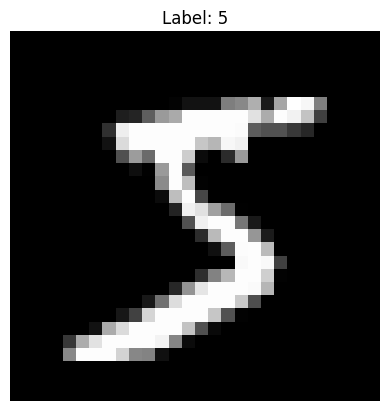

In [16]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")

### Inspecting pixels

Since images are tensors, we can access **individual pixels**.

Tensor shape: ``` [channels, height, width] ```

Example: ``` image[0, row, column] ```


In [17]:
print("Pixel value at (10,10):")
print(image[0,10,10])

Pixel value at (10,10):
tensor(0.0039)


### Exercise

Try to print:

- pixel value at **(5,5)**
- pixel value at **(20,10)**
- 7th column

## 4. DataLoader

Training usually does **not process one sample at a time**.

Instead we process **batches of samples**.

The **DataLoader** automatically:

- groups samples into **batches**
- optionally **shuffles data**
- loads data efficiently

Pipeline: ``` dataset → dataloader → batches ```


`num_workers` — parallel data loading

### Loading data time matters
`num_workers` controls how many processes load data **in parallel (on CPU)**.

```python
DataLoader(dataset, batch_size=32, num_workers=4)
```

- `num_workers = 0` → data loaded **sequentially** (main process)  
- `num_workers > 0` → data loaded **in parallel** (multiple processes)  

---

#### Why it matters

GPU is very fast and can process a batch quickly.  
If data loading is too slow, GPU has to **wait**.

`num_workers` helps prepare the next batches **in advance**, so the GPU stays busy.

---

#### Key idea

> `num_workers` does not speed up GPU computations  
> it prevents GPU from waiting for data

---

#### Practical notes

- more workers ≠ always faster  
- limited by CPU cores and RAM  

Typical values:
- small datasets: `0–2`  
- larger datasets: `4–8`


In [18]:
loader = DataLoader(
    mnist_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

### Iterating over DataLoader

A DataLoader returns **batches**, not single samples.

To access batches we use an **iterator**.

In [19]:
data_iter = iter(loader)
images, labels = next(data_iter)

print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)

Batch shape: torch.Size([32, 1, 28, 28])
Labels shape: torch.Size([32])


(-0.5, 27.5, 27.5, -0.5)

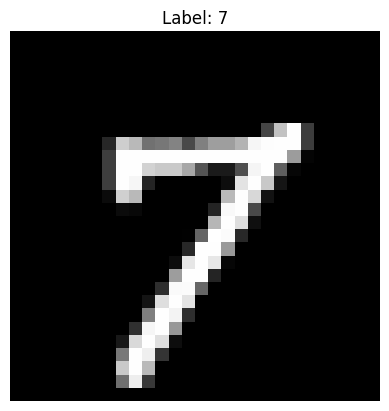

In [20]:
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0]}")
plt.axis("off")

### Exercises

1. Change `batch_size` to **64**, run the cell again and observe how the tensor shape changes.
2. Try to acces single pixel ``` images[image_index, channel, row, column] ```

## 5. Devices (CPU vs GPU)

PyTorch can run computations on:

- CPU
- GPU (CUDA)

GPUs can accelerate deep learning by performing **massively parallel computations**.

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Moving tensors between devices

To run computations on a GPU, tensors must be moved to that device.

``` tensor.to(device) ```

In [22]:
images = images.to(device)
print(images.device)

cuda:0


### Important rule

In PyTorch model and data must be on the same device.


Typical workflow:

``` python 
model.to(device)
data.to(device)
```


### Exercise

Move the `labels` tensor to the same device as `images`.

### Final Conceptual Questions

1. What is the difference between: ``` dataset[0] ``` and ``` next(iter(dataloader)) ```?
2. If ``` images.shape = (32, 1, 28, 28) ``` what does the **first dimension** represent?
3. How would you access the **pixel at row 10 column 5 of image 3**?

## 6.🌟 Why PyTorch?

In [23]:
import torch
import numpy as np

# 1. Creating matrices in NumPy and in PyTorch
np_array = np.array([[1., 2.], [3., 4.]])
torch_tensor = torch.tensor([[1., 2.], [3., 4.]], requires_grad=True)  # tracking gradients

# 2. Element-wise operations
np_result = np_array ** 2
torch_result = torch_tensor ** 2

print("NumPy result:\n", np_result)
print("PyTorch result:\n", torch_result)

# 3. Lets try gradients calculations (only PyTorch)
torch_result.sum().backward()
print("Gradient:\n", torch_tensor.grad)

# 4. GPU
if torch.cuda.is_available():
    torch_tensor_gpu = torch_tensor.to('cuda')
    print("Tensor on GPU:", torch_tensor_gpu)

NumPy result:
 [[ 1.  4.]
 [ 9. 16.]]
PyTorch result:
 tensor([[ 1.,  4.],
        [ 9., 16.]], grad_fn=<PowBackward0>)
Gradient:
 tensor([[2., 4.],
        [6., 8.]])
Tensor on GPU: tensor([[1., 2.],
        [3., 4.]], device='cuda:0', grad_fn=<ToCopyBackward0>)


## 7. 🌟🌟 Why... Python?

Here we have a few examples why Python is so powerful and suitable for machine learning with PyTorch.

### Generators and iterable data pipelines

PyTorch’s `DataLoader` builds on top of Python’s iterator protocol.  
You can feed *any* iterable/iterator into a training loop: live streams, text files, database cursors, etc.

Here we define a simple **streaming generator** that yields synthetic batches.


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

def custom_stream(num_batches, batch_size, input_dim):
    """
       Yield synthetic (x, y) pairs.
       In a real project, this could read from disk, a socket, or a database
       instead of generating random numbers - here it is a nice mock-up test
       of the architecture and pipeline
    """
    for i in range(num_batches):
        x = torch.randn(batch_size, input_dim)
        """ Not only the data matters - need labels too! """
        y = (x.sum(dim=1, keepdim=True) > 0).float()
        yield x, y

def train(model, opt, data_iter):
    model.train()
    total_loss = 0.0
    for x, y in data_iter:
        opt.zero_grad()
        logits = model(x)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    return total_loss

model = nn.Linear(5, 1)
opt = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(5):
    data_iter = custom_stream(num_batches=20, batch_size=32, input_dim=5)
    total_loss = train(model, opt, data_iter)
    print(f"Epoch {epoch}: total loss = {total_loss:.4f}")

Epoch 0: total loss = 13.3620
Epoch 1: total loss = 9.5676
Epoch 2: total loss = 7.7214
Epoch 3: total loss = 6.7370
Epoch 4: total loss = 6.0967


### Context managers for modes and gradient control

PyTorch uses Python’s context manager protocol (the `with` statement) for controlling global (during the training and then evaluation) state:
`torch.no_grad()`, `torch.inference_mode()`, etc. Context managers in Python are the machinery behind the with statement – they define what should happen when you enter and when you leave a block of code.

You can also define **your own** context managers.

In [25]:
# global configuration for our data pipeline
DATA_SCALE = 1


class temporary_data_scale:
    def __init__(self, new_scale):
        self.new_scale = new_scale
        self.old_scale = None

    def __enter__(self):
        global DATA_SCALE
        self.old_scale = DATA_SCALE
        DATA_SCALE = self.new_scale

    def __exit__(self, exc_type, exc_val, exc_tb):
        global DATA_SCALE
        DATA_SCALE = self.old_scale


def process_data(data):
    return [x * DATA_SCALE for x in data]


data = [1, 2, 3]

print("Default processing:", process_data(data))

with temporary_data_scale(10):
    print("Inside context:", process_data(data))

print("After context:", process_data(data))

Default processing: [1, 2, 3]
Inside context: [10, 20, 30]
After context: [1, 2, 3]


### Decorators
Decorators are a Python metaprogramming feature that let you wrap functions with extra behavior. (They are extremely handy for instrumenting training loops: logging, timing, gradient checks, etc.)

Context managers can also be used as decorators. Python provides a utility called `ContextDecorator` that allows a context manager
to also work as a **function decorator**.

This means we can apply the same temporary behavior:

- either to a block of code (`with ...`)
- or to an entire function (`@decorator`)

This pattern is used in many libraries, including PyTorch.
For example:

```python
@torch.no_grad()
def evaluate(model, x):
    return model(x)

```

Below we extend our previous context manager so it can also be used as a decorator.

In [26]:
from contextlib import ContextDecorator

DATA_SCALE = 1

class temporary_data_scale(ContextDecorator):

    def __init__(self, new_scale):
        self.new_scale = new_scale
        self.old_scale = None

    def __enter__(self):
        global DATA_SCALE
        self.old_scale = DATA_SCALE
        DATA_SCALE = self.new_scale

    def __exit__(self, exc_type, exc_val, exc_tb):
        global DATA_SCALE
        DATA_SCALE = self.old_scale


def process_data(data):
    return [x * DATA_SCALE for x in data]


data = [1, 2, 3]


print("Default:", process_data(data))


# --- using it as a context manager ---
with temporary_data_scale(10):
    print("Inside context:", process_data(data))


print("After context:", process_data(data))


# --- using it as a decorator ---
@temporary_data_scale(5)
def process_with_scaling(data):
    return process_data(data)


print("Using decorator:", process_with_scaling(data))

Default: [1, 2, 3]
Inside context: [10, 20, 30]
After context: [1, 2, 3]
Using decorator: [5, 10, 15]


A common practical use of decorator is **measuring execution time** of data processing steps.

This is useful when working with large datasets where we want to understand
how long data loading or preprocessing takes.

The decorator below measures how long a function runs.

In [27]:
import time
import torch


def measure_time(func):
    def wrapper(*args, **kwargs):

        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()

        print(f"{func.__name__} took {end - start:.6f} seconds")
        return result

    return wrapper


@measure_time
def load_data(n):
    # simulate loading data
    data = torch.randn(n, 10)
    return data.mean()


result = load_data(1000000)
print("Result:", result)

load_data took 0.051750 seconds
Result: tensor(6.4980e-05)


#### Exercise

Measure calculation time CPU vs. GPU using ```@measure_time``` decorator

In [28]:
import torch
import time

device_cpu = "cpu"
device_gpu = "cuda" if torch.cuda.is_available() else "cpu"

@measure_time
def performance_test(device):
    size = 10000
    x = torch.randn(size, size, device=device)
    y = torch.randn(size, size, device=device)

    start = time.time()
    z = x @ y
    end = time.time()

print("CPU:")
performance_test(device_cpu)

print("GPU:")
performance_test(device_gpu)

CPU:


performance_test took 2.796701 seconds
GPU:
performance_test took 0.000283 seconds
